In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt,hilbert
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal,linregress
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore



params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   
    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))

In [48]:
### Function to get ACC pupil dilation events

def get_ACC_events(id,date):
    id = id
    date = date
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]

    ##join regions that are near eachother again
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        aucs.append(np.trapz(dff[onset:offset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "aucs" : aucs,
    "mean_dff" : mean_dffs,


    }
    

    return pd.DataFrame.from_dict(events_dict)


In [18]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [19]:
###low pass filter pupil
def filter_pupil(pupil,order = 1,cutoff = 1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y

    return butter_lowpass_filter(pupil, cutoff, fs, order)

In [69]:
###low pass filter face
def filter_face(face,order = 1,cutoff = 0.1,fs = 20):
    def butter_lowpass(cutoff, fs, order=5):
        return butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(data, cutoff, fs, order=5):
        b, a = butter_lowpass(cutoff, fs, order=order)
        y = lfilter(b, a, data)
        return y
    return butter_lowpass_filter(face, cutoff, fs, order)

In [70]:
### Function to get LC facial movement

def get_face_events(id,date):
    id = id
    date = date
    path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
    df = pd.read_csv(path)
    time = df["t"]
    pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
    face = np.array(zscore(df["mot_whisk"]))
    ###Onset detection alogrithm
    filter = filter_face(face) ###first apply low pass filter to face trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
            if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
                offset = start + np.argmin(filter[start:end])
            else:
                offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = len(pupil)
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(face[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)


    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    #"mean_dff" : mean_dffs,
    }
    return pd.DataFrame.from_dict(events_dict)


In [ ]:
### Function to get LC pupil dilation evens

def get_pupil_events(id,date):
    id = id
    date = date
    path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
    df = pd.read_csv(path)
    time = df["t"]
    pupil = np.array(zscore(df["pupil"])) ###zscore pupil data

    ###Onset detection alogrithm
    filter = filter_pupil(pupil) ###first apply low pass filter to pupil trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last pupil event
    start = region_ix[-1][-1]
    end = len(pupil)
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get pupil event amplitudes
    amplitudes = []
    amplitudes_ix = []
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(filter[on:off]))

    ###get pupil event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)


    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    }

    return pd.DataFrame.from_dict(events_dict)

In [85]:
### Function to get ACC facial movement aligned events

def get_ACCface_events(id,date):
    id = id
    date = date
    #face_path = f"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/ethanol_data/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    #path = f"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/ethanol_data/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
    path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
    df = pd.read_csv(path)
    pupil = np.array(df["Pupil Size"])
    time = np.array(df["Time"])
    speed = np.array(df["Running Speed"])
    speed[0] = 0
    dff = np.array(df["dFF"])
    face = np.array(pd.read_csv(face_path)["Facial Movement"])

    ###Onset detection alogrithm

    
    filter = filter_face(face) ###first apply low pass filter to face trace

    def groupSequence(x): 
        it = iter(x) 
        prev, res = next(it), [] 
    
        while prev is not None: 
            start = next(it, None) 
    
            if start and start > prev:

                res.append(prev) 
            elif res: 
                yield list(res + [prev]) 
                res = [] 
            prev = start 


    regions = list(groupSequence(filter))
    corrected_regions = [region for region in regions if len(region) >=15 ] ###only include regions that are >750ms
    corrected_regions = [region for region in corrected_regions if region[0]<np.median(filter) ] ###only include onsets that occur below z = median

    region_ix = [[np.where(filter == val)[0][0] for val in region] for region in corrected_regions] ### get indices for each region


    ##join regions that are near eachother
    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>20:
                if start-end<= 20:
                    #print(first[0]/20,second[0]/20)
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]


    new = []
    for i,first in enumerate(region_ix):
        if i < len(region_ix)-1:
            second = region_ix[i + 1]
            end = first[-1]
            start = second[0]
            if first[0] - region_ix[i - 1][-1]>10:
                if start-end<= 10:
                    new.append(first + second)
                else:
                    new.append(first)
    region_ix = new
    corrected_regions = [filter[region[0]:region[-1]] for region in region_ix]
    onsets_ix = [region[0] for region in region_ix]


    ###get offsets and durations for pupil event
    offset_ix = []
    durations = []
    for i,(region,index) in enumerate(zip(corrected_regions,region_ix)):
        if i < len(region_ix)-1:
            start = index[-1] ###end of region
            end = region_ix[i+1][0] ### start of next region
            onset_y = region[0]
            offsets = np.where(filter[start:end] <= onset_y) ###find ix of first point that goes below onset 
        if len(offsets[0]) == 0: ###if it never goes below onset then use lowest value
            offset = start + np.argmin(filter[start:end])
        else:
            offset = start + offsets[0][0]


        offset_ix.append(offset)

        durations.append((offset-index[0])/20)

    ###handle last face event
    start = region_ix[-1][-1]
    end = 36000
    onset_y = corrected_regions[-1][0]
    offsets = np.where(filter[start:end] <= onset_y)
    if len(offsets[0]) == 0:
        offset = end-1
    else:
        offset = start + np.argmin(filter[start:end])

    offset_ix[-1] = offset

    durations[-1] = (offset-region_ix[-1][0])/20

    ###get face event amplitudes
    amplitudes = []
    amplitudes_ix = []
    ###change to align to raw peak
    for on,off in zip(onsets_ix,offset_ix):
        #print(on,off)
        amplitudes.append(max(filter[on:off])-filter[on])
        amplitudes_ix.append(on + np.argmax(face[on:off]))


    ###get face event slopes
    slopes = []
    for region in corrected_regions:
        run = len(region)/20
        rise = region[-1]-region[0]
        slopes.append(rise/run)

    ###get dff data
    aucs = []
    peak_dffs = []
    mean_dffs = []
    for onset,offset in zip(onsets_ix,offset_ix):
        baseline = np.mean(dff[onset-40:onset-10])
        peak_dffs.append(max(dff[onset:offset]) - np.mean(dff[onset-30:onset]))
        mean_dffs.append(np.mean(dff[onset:offset])- np.mean(dff[onset-20:onset]))

    ###create dictionary

    events_dict = {"durations" :durations,
    "amplitudes": amplitudes,
    "slopes" : slopes,
    "onsets" : onsets_ix,
    "offsets" : offset_ix,
    "peak_ix" : amplitudes_ix,
    "ID" : [id] * len(durations),
    "Date" : [date] * len(durations),
    "peak_dff" : peak_dffs,
    "mean_dff" : mean_dffs,
    }
    return pd.DataFrame.from_dict(events_dict)


In [17]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [21]:
### Get ACC data for Fig7B
id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}
df_list = []


for id,dates in id_date.items():
    for date in dates:
      face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
      path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
      df = pd.read_csv(path)
      pupil = np.array(df["Pupil Size"])
      time = np.array(df["Time"])
      speed =zscore(np.array(df["Running Speed"]))
      dff = np.array(df["dFF"])
      face = np.array(pd.read_csv(face_path)["Facial Movement"])
      df["Facial Movement"] = face
      new_dict = {"R":pearsonr(dff,pupil)[0], "type": "P-D", "ID" : id, "Date": date,"Region":"ACC"}
      df_list.append(new_dict)
      new_dict = {"R":pearsonr(dff,face)[0], "type": "F-D", "ID" : id, "Date": date,"Region":"ACC"}
      df_list.append(new_dict)

acc_r_df = pd.DataFrame.from_dict(df_list)

In [22]:
### Get LC data for Fig7B

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}
df_list = []


for id,dates in id_date.items():
    for date in dates:
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        new_dict = {"R":pearsonr(dff,pupil)[0], "type": "P-D", "ID" : id, "Date": date,"Region":"LC"}
        df_list.append(new_dict)
        new_dict = {"R":pearsonr(dff,face)[0], "type": "F-D", "ID" : id, "Date": date,"Region":"LC"}
        df_list.append(new_dict)

lc_r_df = pd.DataFrame.from_dict(df_list)

### Combine into one correlation df
r_df = pd.concat([lc_r_df,acc_r_df])

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/2584332741.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "R",errorbar="se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/2584332741.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)


Text(0, 0.5, 'P-D Correlation (R)')

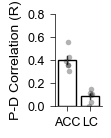

In [23]:
### Plot Fig7B (Left)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "R",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'P-D'"), x = "Region", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.2,1,0.2))
g.set(ylim=(0, 0.8))
g.set_ylabel("P-D Correlation (R)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/4003086837.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "R",errorbar="se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/4003086837.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)


Text(0, 0.5, 'F-D Correlation (R)')

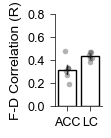

In [24]:
### Plot Fig7B (Right)
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "R",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = r_df.groupby(["ID",'type',"Region"]).mean().reset_index().query("type == 'F-D'"), x = "Region", y = "R",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.2,1,0.2))
g.set(ylim=(0, 0.8))
g.set_ylabel("F-D Correlation (R)")

In [ ]:
### Get data for Fig7C (Left)

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],



}



df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
   
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = filter_pupil(np.array(zscore(df["pupil"]))) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        onsets = [time[on] for on in events["onsets"]]


       

        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )
        

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)


pupil_onset_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1754478955.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = pupil_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Pupil'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)


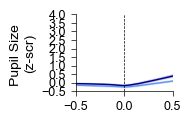

In [ ]:
### Plot Fig7C (Top Left)
plt.figure(figsize = (1.25,1))
ax = sns.lineplot(data = pupil_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Pupil'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Pupil Size \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,0.5),(-0.5,4),0.5,0.5)



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1034941852.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = pupil_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


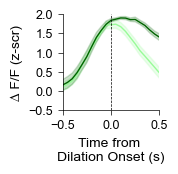

In [ ]:
### Plot Fig7C (Bottom Left)
plt.figure(figsize = (1.25,1.25))
ax = sns.lineplot(data = pupil_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.set_xlabel("Time from \nDilation Onset (s)")
ax.set_ylabel("∆ F/F (z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,0.5),(-0.5,2),0.5,0.5)

In [ ]:
### Get data for Fig7C (Right)

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = filter_pupil(np.array(zscore(df["pupil"]))) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        peaks = [time[on] for on in events["peak_ix"]]
        dil_matrix,dil_times = trial_align(peaks,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(peaks,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

pupil_peak_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/3369851495.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = pupil_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Pupil'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)


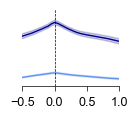

In [ ]:
### Plot Fig7C (Top Right)
plt.figure(figsize = (1.25,1))
ax = sns.lineplot(data = pupil_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'Pupil'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["cornflowerblue","darkblue"],legend = None,linewidth = 1)
#ax.set_xlabel("Time from \nDilation Peak (s)")
ax.xaxis.label.set_visible(False)

ax.set_ylabel("Pupil Size \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,1),(-0.5,4),0.5,0.5)
ax.spines[['left']].set_visible(False)
ax.get_yaxis().set_visible(False)
#plt.savefig(rf"/Users/nithik/Library/CloudStorage/Box-Box/HUDA_LAB_DATA/Manuscripts/2023-ACCArousal-CurrentBiology/SavedGraphs/LC_pupil_peakquartile_line.pdf",format ="pdf",transparent = True,bbox_inches = "tight")



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/2793013658.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = pupil_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


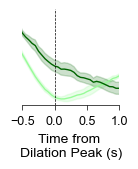

In [ ]:
### Plot Fig7C (Bottom Right)
plt.figure(figsize = (1.25,1.25))
ax = sns.lineplot(data = pupil_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.set_xlabel("Time from \nDilation Peak (s)")
ax.set_ylabel("∆ F/F (z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,1),(-0.5,2),0.5,0.5)
ax.spines[['left']].set_visible(False)
ax.get_yaxis().set_visible(False)

In [ ]:
### Get dataframe for Panel B

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}
labels = ["1","2","3","4"]
df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = labels))
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        for i,(on,off) in enumerate(zip(onsets,offsets)):
          baseline = np.mean(dff[on - 40:on - 10])
          pre_dff =np.mean(dff[on-5:on]) - baseline
          during_dff = np.mean(dff[on:off]) - baseline
          new_dict = { "trial" : i,"ID" : id, "Date": date,"amp":amplitudes[i],"animal_amp_bin":binned_amps[i],"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff}
          df_list.append(new_dict)

pupil_bar_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1423064994.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.pointplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",errorbar = "se",scale = 0.5,errwidth= 1.2,color ="black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1423064994.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",units = "ID",estimator = None,col

[(0.0, 2.0)]

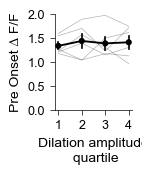

In [45]:
### Plot Fig7D (Left)
plt.figure(figsize = (1,1.25))
g = sns.pointplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",errorbar = "se",scale = 0.5,errwidth= 1.2,color ="black")
sns.lineplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_xlabel("Dilation amplitude\n quartile")
g.set_yticks(np.arange(0,2.5,0.5))
g.set(ylim=(0,2))

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1727923048.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.pointplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",errorbar = "se", scale = 0.5,errwidth= 1.2,color = "black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1727923048.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha

[(0.0, 0.5)]

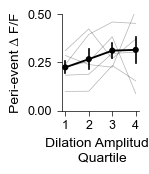

In [46]:
### Plot Fig7D (Right)
plt.figure(figsize = (1,1.25))
g = sns.pointplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",errorbar = "se", scale = 0.5,errwidth= 1.2,color = "black")
sns.lineplot(data = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_ylabel("Peri-event ∆ F/F")
g.set_xlabel("Dilation Amplitude\n Quartile")
g.set_yticks(np.arange(0,0.75,0.25))
g.set(ylim=(0,0.5))


In [59]:
### Get ACC data for Fig7E

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}
labels = ["1","2","3","4"]
df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACC_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = labels))
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        for i,(on,off) in enumerate(zip(onsets,offsets)):
          baseline = np.mean(dff[on - 40:on - 10])
          pre_dff =np.mean(dff[on-5:on]) - baseline
          during_dff = np.mean(dff[on:off]) - baseline
          new_dict = { "trial" : i,"ID" : id, "Date": date,"amp":amplitudes[i],"animal_amp_bin":binned_amps[i],"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff}
          df_list.append(new_dict)
          
acc_bar_df = pd.DataFrame.from_dict(df_list)

### Get the linear fit of each animal ampbin to delta dff

df = acc_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()

slopes = []

# Group by 'ID'
for mouse_id, group in df.groupby('ID'):
    x = [1,2,3,4]
    y = np.array(group['∆ F/F'])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Store the slope with the corresponding mouse ID
    slopes.append({'ID': mouse_id, 'Slope': slope})

# Convert to DataFrame for better visualization
acc_slope_df = pd.DataFrame(slopes)
acc_slope_df["Region"] = "ACC"


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/3764346291.py:42: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = acc_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()


In [60]:
### Get LC data for Fig7E

df = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()

slopes = []

# Group by 'ID'
for mouse_id, group in df.groupby('ID'):
    x = [1,2,3,4]
    y = np.array(group['∆ F/F'])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Store the slope with the corresponding mouse ID
    slopes.append({'ID': mouse_id, 'Slope': slope})

# Convert to DataFrame for better visualization
lc_slope_df = pd.DataFrame(slopes)
lc_slope_df["Region"] = "LC"



/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/2905327850.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = pupil_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()


In [61]:
### Combine into one slope df for Fig7E
slope_df = pd.concat([lc_slope_df,acc_slope_df])

Text(0, 0.5, 'Slope')

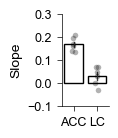

In [63]:
### Plot Fig7E
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = slope_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Slope",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = slope_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Slope",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.1,0.4,0.1))
g.set(ylim=(-0.1, 0.3))
g.set_ylabel("Slope")

In [64]:
### Get ACC data for Fig7F

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACC_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore(np.array(df["Running Speed"]))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])
        for i,(on,peak) in enumerate(zip(onsets_ix,peak_ix)):
            delta = dff[peak] - dff[on]
            new_dict = { "trial" : i,"ID" : id, "Date": date,"Peak-Onset":delta,"Region":"ACC"}
            df_list.append(new_dict)

acc_peakonset_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Get LC data for Fig7F

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_pupil_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        for i,(on,peak) in enumerate(zip(onsets_ix,peak_ix)):
            delta = dff[peak] - dff[on]
            new_dict = { "trial" : i,"ID" : id, "Date": date,"Peak-Onset":delta,"Region":"LC"}
            df_list.append(new_dict)

lc_peakonset_df = pd.DataFrame.from_dict(df_list)


In [67]:
### Combine into one df for Fig7F
peakonset_df = pd.concat([lc_peakonset_df,acc_peakonset_df])

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/3494979315.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = peakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",errorbar="se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/3494979315.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = peakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1)


Text(0, 0.5, 'Peak - Onset (∆ F/F)')

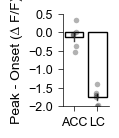

In [ ]:
### Plot Fig7F
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = peakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = peakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-2,1,0.5))
g.set(ylim=(-2, 0.5))
g.set_ylabel("Peak - Onset (∆ F/F)")

In [ ]:
### Get data for Fig7G (Left)

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],



}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_face_events(id,date)
        #onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
   
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        ###do not filter
        pupil = filter_pupil(zscore(np.array(df["pupil"])))
        time = df["t"]
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        face = zscore(np.array(df["mot_whisk"]))
        onsets = [time[on_ix] for on_ix in events["onsets"]]
        dil_matrix,dil_times = trial_align(onsets,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(onsets,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(onsets,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

face_onset_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/908344538.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = face_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'face'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["violet","purple"],legend = None,linewidth = 1)


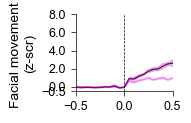

In [ ]:
### Plot Fig7G (Top Right)
plt.figure(figsize = (1.25,1))
ax = sns.lineplot(data = face_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'face'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["violet","purple"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Facial movement \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,0.5),(-0.5,8),0.5,0.5)
ax.set_yticks([-0.5,0,2,4,6,8])

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/725727950.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = face_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


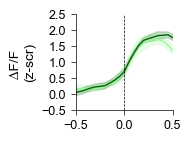

In [ ]:
### Plot Fig7G (Bottom Left)
plt.figure(figsize = (1.25,1.25))
ax = sns.lineplot(data = face_onset_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("∆F/F \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
format_ax(ax,(-0.5,0.5),(-0.5,2.5),0.5,0.5)

In [75]:
### Create dataframe for LC
### Aligned to face peak

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],



}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_face_events(id,date)

        onsets = [on/20 for on in events["onsets"]] ###get pupil onsets
        onsets_ix = events["onsets"]
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = [1,2,3,4]))
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        pupil = zscore(np.array(df["pupil"]))
        time = df["t"]
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        face = zscore(np.array(df["mot_whisk"]))
        peaks = [time[ix] for ix in events["peak_ix"]] ### get pupil peaks
        dil_matrix,dil_times = trial_align(peaks,time,pupil,fps = 20,pre = 10, post = 10 )

        for j,trial in enumerate(dil_matrix):
            baseline = np.mean(pupil[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(dil_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "Pupil","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

        trial_matrix,trial_times = trial_align(peaks,time,dff,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(trial_matrix):
            baseline = np.mean(dff[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(trial_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "dff","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)
        
        face_matrix,face_times = trial_align(peaks,time,face,fps = 20,pre = 10, post = 10)
        for j,trial in enumerate(face_matrix):
            baseline = np.mean(face[onsets_ix[j] - 40:onsets_ix[j] - 10])
            trial = trial - baseline
            for i,Time in enumerate(face_times):
                new_dict = {"Time from Onset (s)" : Time, "trial" : j, "value" : trial[i], "type" : "face","ID" : id, "Date": date,"amp":amplitudes[j],"animal_amp_bin":binned_amps[j]}
                df_list.append(new_dict)

face_peak_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/2105951898.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = face_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'face'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["violet","purple"],legend = None,linewidth = 1)


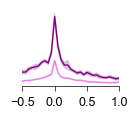

In [ ]:
### Plot Fig 7G (Top Right)
plt.figure(figsize = (1.25,1))
ax = sns.lineplot(data = face_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'face'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["violet","purple"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("Facial movement \n(z-scr)")
ax.spines[['left']].set_visible(False)
ax.get_yaxis().set_visible(False)
format_ax(ax,(-0.5,1),(-0.5,9),0.5,0.5)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/222196424.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = face_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)


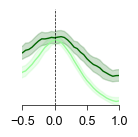

In [77]:
### Plot Fig 7G (Bottom Right)
plt.figure(figsize = (1.25,1.25))
ax = sns.lineplot(data = face_peak_df.groupby(["ID","Time from Onset (s)","type","animal_amp_bin"]).mean().reset_index().query("type == 'dff'").query("animal_amp_bin == [1,4]"), x = "Time from Onset (s)", y = "value",errorbar = "se",hue = "animal_amp_bin",palette= ["palegreen","darkgreen"],legend = None,linewidth = 1)
ax.xaxis.label.set_visible(False)
ax.set_ylabel("∆F/F \n(z-scr)")
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.spines[['left']].set_visible(False)
ax.get_yaxis().set_visible(False)
format_ax(ax,(-0.5,1),(-0.5,2.5),0.5,0.5)

In [78]:
### Get data for Fig7H

id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"]
}
labels = ["1","2","3","4"]
df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_face_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = labels))
     

        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        pupil = zscore(np.array(df["pupil"]))
        time = df["t"]
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        face = zscore(np.array(df["mot_whisk"]))
        for i,(on,off) in enumerate(zip(onsets,offsets)):
          baseline = np.mean(dff[on - 40:on - 10])
          pre_dff =np.mean(dff[on-5:on]) - baseline
          during_dff = np.mean(dff[on:off]) - baseline
          new_dict = { "trial" : i,"ID" : id, "Date": date,"amp":amplitudes[i],"animal_amp_bin":binned_amps[i],"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff}
          df_list.append(new_dict)

face_bar_df = pd.DataFrame.from_dict(df_list)


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/20350367.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.pointplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",errorbar = "se",scale = 0.5, errwidth= 1.2,color ="black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/20350367.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",units = "ID",estimator = None,color = 

[(-0.25, 0.75)]

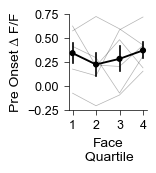

In [ ]:
### Plot Fig 7H (Left)
plt.figure(figsize = (1,1.25))
g = sns.pointplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",errorbar = "se",scale = 0.5, errwidth= 1.2,color ="black")
sns.lineplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "Pre Onset ∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_xlabel("Face\n Quartile")
g.set_yticks(np.arange(-0.25,1,0.25))
g.set(ylim=(-0.25,0.75))


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1678511537.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.pointplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",errorbar = "se", scale = 0.5,errwidth= 1.2,color = "black")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1678511537.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha =

[(-0.5, 1.0)]

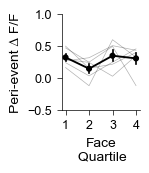

In [81]:
### Plot Fig 7H (Right)
plt.figure(figsize = (1,1.25))
g = sns.pointplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",errorbar = "se", scale = 0.5,errwidth= 1.2,color = "black")
sns.lineplot(data = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index(), x = "animal_amp_bin", y = "∆ F/F",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
g.set_ylabel("Peri-event ∆ F/F")
g.set_xlabel("Face\n Quartile")
g.set_yticks(np.arange(-0.5,2,0.5))
g.set(ylim=(-0.5,1))


In [87]:
### Create dataframe for Panel D

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}
labels = ["1","2","3","4"]
df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACCface_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        binned_amps = np.array(pd.qcut(amplitudes,q = 4,labels = labels))
     

  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore((np.array(df["Running Speed"])))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

      
        for i,(on,off) in enumerate(zip(onsets,offsets)):
          baseline = np.mean(dff[on - 40:on - 10])
          pre_dff =np.mean(dff[on-5:on]) - baseline
          during_dff = np.mean(dff[on:off]) - baseline


          new_dict = { "trial" : i,"ID" : id, "Date": date,"amp":amplitudes[i],"animal_amp_bin":binned_amps[i],"Pre Onset ∆ F/F":pre_dff,"∆ F/F": during_dff}
          df_list.append(new_dict)


acc_facebar_df = pd.DataFrame.from_dict(df_list)

### Get linear fit of each ACC animal ampbin to delta dff

df = acc_facebar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()

slopes = []

# Group by 'ID'
for mouse_id, group in df.groupby('ID'):
    x = [1,2,3,4]
    y = np.array(group['∆ F/F'])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Store the slope with the corresponding mouse ID
    slopes.append({'ID': mouse_id, 'Slope': slope})

# Convert to DataFrame for better visualization
acc_faceslope_df = pd.DataFrame(slopes)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/1207115405.py:50: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = acc_facebar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()


In [89]:
### Get linear fit of each LC animal ampbin to delta dff

df = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()

slopes = []

# Group by 'ID'
for mouse_id, group in df.groupby('ID'):
    x = [1,2,3,4]
    y = np.array(group['∆ F/F'])
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    
    # Store the slope with the corresponding mouse ID
    slopes.append({'ID': mouse_id, 'Slope': slope})

# Convert to DataFrame for better visualization
lc_faceslope_df = pd.DataFrame(slopes)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/193669075.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = face_bar_df.groupby(["ID",'animal_amp_bin']).mean().reset_index()


In [90]:
### Combine into one df for Fig7I
lc_faceslope_df["Region"] = "LC"
acc_faceslope_df["Region"] = "ACC"
slope_df = pd.concat([lc_faceslope_df,acc_faceslope_df])

Text(0, 0.5, 'Slope')

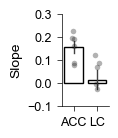

In [ ]:
### Plot Fig7I
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = slope_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Slope",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = slope_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Slope",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-0.1,0.4,0.1))
g.set(ylim=(-0.1, 0.3))
g.set_ylabel("Slope")

In [92]:
### Get ACC data for Fig7J

id_date = {
  "004113":["20230808"],
  "004114":["20230808","20230815"],
  "004115":["20230804","20230808","20230815"],
  "004116":["20230804","20230808","20230815"],
  "004117":["20230804","20230808","20230815"],
  "004118":["20230804","20230808","20230815"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_ACCface_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
     
     

  
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_FaceProcessed.csv"
        path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_ProcessedData.csv"
        df = pd.read_csv(path)
        pupil = np.array(df["Pupil Size"])
        time = np.array(df["Time"])
        speed = zscore(np.array(df["Running Speed"]))
        dff = np.array(df["dFF"])
        face = np.array(pd.read_csv(face_path)["Facial Movement"])

        for i,(on,peak) in enumerate(zip(onsets_ix,peak_ix)):
            delta = dff[peak] - dff[on]
            new_dict = { "trial" : i,"ID" : id, "Date": date,"Peak-Onset":delta,"Region":"ACC"}
            df_list.append(new_dict)

acc_facepeakonset_df = pd.DataFrame.from_dict(df_list)


In [93]:
###


id_date = {
  "LC01":["20240419"],
  "LC02":["20240416"],
  "LC03":["20240419"],
  "LC04":["20240416","20240417"],
  "LC05":["20240513"],
  "LC06":["20240513"],
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
      
        events = get_face_events(id,date)
        peak_ix = events["peak_ix"]
        onsets = [on for on in events["onsets"]] ###get pupil onsets ix
        onsets_ix = events["onsets"]
        offsets = [off for off in events["offsets"]] ###get pupil offsets ix
        amplitudes = events["amplitudes"]
        path = f"{base_dir}/{id}/{date}/{id}_{date}_fixed.csv"
        df = pd.read_csv(path)
        time = df["t"]
        pupil = np.array(zscore(df["pupil"])) ###zscore pupil data
        face = np.array(zscore(df["mot_whisk"]))###zscore face data
        dff = np.array(zscore(df["fp_lc"])) ###zscore dff data
        for i,(on,peak) in enumerate(zip(onsets_ix,peak_ix)):
            delta = dff[peak] - dff[on]

            new_dict = { "trial" : i,"ID" : id, "Date": date,"Peak-Onset":delta,"Region":"LC"}
            df_list.append(new_dict)


lc_facepeakonset_df = pd.DataFrame.from_dict(df_list)


In [95]:
### Combine into one df for Fig7J
facepeakonset_df = pd.concat([lc_facepeakonset_df,acc_facepeakonset_df])

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/713487745.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = facepeakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",errorbar="se",fill = None,errwidth= 1)
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_4096/713487745.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = facepeakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1)


Text(0, 0.5, 'Peak - Onset (∆ F/F)')

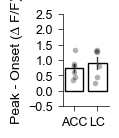

In [96]:
###LC vs ACC face-dff peak - onset
plt.figure(figsize = (0.6,1.2))
g = sns.barplot(data = facepeakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",errorbar="se",fill = None,errwidth= 1)
sns.stripplot(data = facepeakonset_df.groupby(["ID","Region"]).mean().reset_index(), x = "Region", y = "Peak-Onset",color = "black",alpha = 0.3,s = 4,jitter = 0.1)
g.xaxis.label.set_visible(False)
g.set_yticks(np.arange(-2,3,0.5))
g.set(ylim=(-0.5, 2.5))
g.set_ylabel("Peak - Onset (∆ F/F)")

